## Lib integration

In [1]:
import sys
# sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching")
sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching\demo-code\2d")
import h5py
from collections import defaultdict, Counter
import numpy as np
from rich import print

In [2]:
file_path = r"E:\Dai hoc\2526I\dacn\flow-matching\data\traintest_hcd.hdf5"

## Open data

In [3]:
with h5py.File(file_path, "r") as f:
    print("Keys:", list(f.keys()))

    seqs = f["sequence_integer"][:]
    charges_oh = f["precursor_charge_onehot"][:]
    intensities = f["intensities_raw"][:]  

Keys:
[
    'collision_energy',
    'collision_energy_aligned',
    'collision_energy_aligned_normed',
    'intensities_raw',
    'masses_pred',
    'masses_raw',
    'method',
    'precursor_charge_onehot',
    'rawfile',
    'reverse',
    'scan_number',
    'score',
    'sequence_integer',
    'sequence_onehot'
]

In [4]:
charges = np.argmax(charges_oh, axis=1) + 1
del charges_oh

In [5]:
seqs[0]

array([19,  4, 18, 20, 13, 18, 12, 16, 17,  5, 15, 18, 10, 18, 16,  6,  1,
       17, 15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

### Utils

### Peak data

In [6]:
# np.argmax(charges_oh, axis=1) + 1

In [7]:
len(intensities[0])

174

In [8]:
# max_index = 0
# for seq in seqs:
#     for token in seq:
#         if token > max_index:
#             max_index = token
# print("Max token index:", max_index)

## Explore data

## FLow matching training

In [9]:
import torch
torch.set_default_device("cuda")
from torch import nn
# from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import imageio
from sklearn.datasets import make_moons
import math

from coupling import mini_batch_coupling, greedy_coupling, sinkhorm_coupling
from draw import DrawFlow, DrawSample
from gen_path import get_xt
from flow_model import HCDFlowResMLP, HCDFlow

### Training configuration

In [ ]:
epoch = 2000
batch_size = 512
model = HCDFlowResMLP(noise_dim=174, pep_dim=256, time_dim=128, charge_dim=128)
optimizer = torch.optim.AdamW(model.parameters(), eps=1e-10, lr=3e-4,weight_decay=1e-2)
warmup_steps = int(0.02 * epoch)
lr_max = 3e-4
lr_min = 3e-6

def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / (epoch - warmup_steps)
    return lr_min / lr_max + 0.5 * (1 - lr_min / lr_max) * (1 + math.cos(math.pi * progress))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


#### Tranable params

In [11]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

4959534

In [12]:
# torch.save(model.state_dict(), "model.pth")

In [ ]:
from tqdm.auto import tqdm
# pbar = tqdm(range(int(epoch)), desc="Training")
loss_history = []
last_100_loss = []
pbar = tqdm(range(int(epoch)), desc="Training")
for ep in pbar:
    model.train()
    batch_indices = np.random.choice(len(intensities), batch_size, replace=False)
    batch_intensities = torch.tensor(intensities[batch_indices], dtype=torch.float32)
    batch_pep_seq = torch.tensor(seqs[batch_indices], dtype=torch.long)
    batch_charge = torch.tensor(charges[batch_indices], dtype=torch.float32).unsqueeze(1)
    
    noise = torch.randn_like(batch_intensities)
    t = torch.rand(batch_size, 1)
    x_t = get_xt(batch_intensities, noise, t)
    # print(x_t.shape, t.shape, batch_pep_seq.shape, batch_charge.shape)
    u_pred = model(x_t, t=t, pep_seq=batch_pep_seq, charge=batch_charge)
    loss = nn.MSELoss()(u_pred, batch_intensities - noise)
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    scheduler.step()

    last_100_loss.append(loss.item())
    if (ep + 1) % 100 == 0:
        mean_last_100 = sum(last_100_loss)/len(last_100_loss)
        last_100_loss.clear()
        loss_history.append(mean_last_100)
        pbar.set_postfix({
            "Loss": f"{loss.item():.4f}", 
            "Avg Loss 100": f"{(mean_last_100):.4f}",
            "LR": f"{scheduler.get_last_lr()[0]:.2e}"
            })

Training:   0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

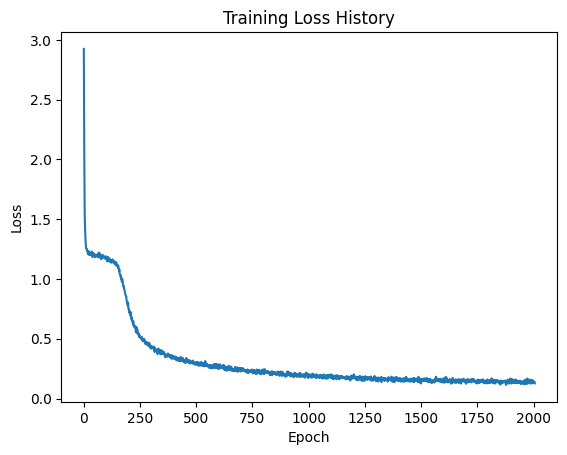

In [14]:
import matplotlib.pyplot as plt

def plot_loss_history(loss_history, smooth_window=None):
    """
    Plot training loss history.
    
    Args:
        loss_history (list or array): Danh sách loss theo từng step/epoch.
        smooth_window (int, optional): Nếu truyền vào, sẽ vẽ thêm đường smooth
                                       bằng moving average với window này.
    """
    plt.figure()
    plt.plot(loss_history)
    
    if smooth_window is not None and smooth_window > 1:
        import numpy as np
        loss_array = np.array(loss_history)
        kernel = np.ones(smooth_window) / smooth_window
        smooth_loss = np.convolve(loss_array, kernel, mode='valid')
        plt.plot(range(smooth_window - 1, len(loss_history)), smooth_loss)
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss History")
    plt.show()

plot_loss_history(loss_history)

## Pearson Correlation Coefficent

In [ ]:
def pcc_per_sample(Y_true, Y_pred):
    Y_true = Y_true - Y_true.mean(dim=1, keepdim=True)
    Y_pred = Y_pred - Y_pred.mean(dim=1, keepdim=True)

    covariance = (Y_true * Y_pred).sum(dim=1)
    std_true = torch.sqrt((Y_true ** 2).sum(dim=1))
    std_pred = torch.sqrt((Y_pred ** 2).sum(dim=1))

    pcc = covariance / (std_true * std_pred + 1e-8)

    return pcc.mean().item()


In [ ]:
test_seq = seqs[0]
test_charge = charges[0]
test_intensities = []
for seq, charge, intensity in zip(seqs, charges, intensities):
    
    if np.array_equal(seq, test_seq) and test_charge == charge:
        test_intensities.append(intensity)
len(test_intensities)

In [ ]:
with torch.no_grad():
    model.eval()
    test_pep_seq = torch.tensor(test_seq, dtype=torch.long).unsqueeze(0)
    test_charge_tensor = torch.tensor(test_charge, dtype=torch.float32).unsqueeze(0).unsqueeze(1)
    test_intensities_tensor = torch.tensor(test_intensities, dtype=torch.float32)
    
    num_samples = len(test_intensities)
    noise = torch.randn(num_samples, *test_intensities_tensor[0].shape)
    
    test_pep_seq = test_pep_seq.repeat(num_samples, 1)
    test_charge_tensor = test_charge_tensor.repeat(num_samples, 1)
    pred_intentities = model.sample(noise,test_pep_seq, test_charge_tensor, step=10)
    # print(pred_intentities - test_intensities_tensor)
    
    pcc_value = pcc(test_intensities_tensor, pred_intentities)
    print(f"PCC: {pcc_value:.4f}")

In [ ]:
test_intensities_tensor.shape